Task:
Simulate 1000 random current in the range (0.01, 1.5) in scenario A, 
given 
- current $I_1$ at position 1 of `qrodrupole focusing Lattice`(beamline 0.35878m - 0.44768m) and $I_3$ at position 3 of `qrodrupole defocusing Lattice`(beamline 0.64453m - 0.73342m),
- objective that $\alpha_x=0$ at position 8, and $\alpha_y=0$ at position 9
- weight for each objective(both 1 for `$\alpha_x=0$ at position 8` and `$\alpha_y=0$ at position 9`)

return 
- weighted MSE function $\phi(k)$
- Jacobian matrix $J(k) \in \mathbb{R}^{2 \times 2}$
- Hessian matrix $H(k) \in \mathbb{R}^{2 \times 2}$
- Eigenvalues/Eigenvectors of Hessian matrix $H(k)$

In [41]:
import numpy as np
import torch
import copy
import time
import pickle
import os, sys
current_dir=os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.join(current_dir, "../")))
sys.path.insert(0, os.path.abspath(os.path.join(current_dir, "../../backend")))
# print(sys.path)

# Initialize the beamline
from configs import *
from experiments_utils import load_results, save_results
from ebeam import beam as ebeam_class
from beamline import lattice
from excelElements import ExcelElements
from beamOptimizer import beamOptimizer
import importlib
import SOBOL_scan
importlib.reload(SOBOL_scan)
from SOBOL_scan import *

compute the weighted MSE function $\phi(k)$ for scenario A, evalutated at position 8 for $\alpha_x$ and position 9 for $\alpha_y$

In [42]:
I_dict_test = {"I": 0.7469, "I2": 0.5819, "I3": 0.4}

A_VARS_test = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
    10: ["I3", "current", lambda x: x],
}
A_OBJ_test = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
    12: [{"measure": ["x", "beta"], "goal": 0.0, "weight": 1.0}],
}

r, phi, time_elasted = compute_weighted_MSE(I_dict_test, A_VARS_test, A_OBJ_test)
# r, phi = res
print(f"R vector: {r}")
print(f"Phi value: {phi}")
print(f"Time taken: {time_elasted:.4f} seconds")
# print(compute_weighted_MSE(I_dict_test, A_VARS_test, A_OBJ_test))

R vector: [ 0.02988673 -0.00254803  0.56780513]
Phi value: 0.21553491390488458
Time taken: 3.2215 seconds


compute Jacobian matrix $J(k)$ for scenario A, with dimension $2 \times 2$, evaluated at position 8 for $\alpha_x$ and position 9 for $\alpha_y$

In [43]:
print(f"Original currents: {I_dict_test}")
print(f"Perturbed currents (plus delta): {perturb_currents(I_dict_test, delta=1e-5)[0]}")
print(f"Perturbed currents (minus delta): {perturb_currents(I_dict_test, delta=1e-5)[1]}")


Original currents: {'I': 0.7469, 'I2': 0.5819, 'I3': 0.4}
Perturbed currents (plus delta): {0: {'I': 0.74691, 'I2': 0.5819, 'I3': 0.4}, 1: {'I': 0.7469, 'I2': 0.5819099999999999, 'I3': 0.4}, 2: {'I': 0.7469, 'I2': 0.5819, 'I3': 0.40001000000000003}}
Perturbed currents (minus delta): {0: {'I': 0.74689, 'I2': 0.5819, 'I3': 0.4}, 1: {'I': 0.7469, 'I2': 0.58189, 'I3': 0.4}, 2: {'I': 0.7469, 'I2': 0.5819, 'I3': 0.39999}}


In [44]:
I_dict_test = {"I": 0.7469, "I2": 0.5819, "I3": 0.4, "I4": 0.5}
A_VARS_test = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
    tunable_current[2]: ["I3", "current", lambda x: x],
    tunable_current[3]: ["I4", "current", lambda x: x],
}
A_OBJ_test = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}
J, time_elasted = compute_jacobian(I_dict_test, A_VARS_test, A_OBJ_test)
print(f"Jacobian matrix J(k):\n{J}") 
print(f"Time taken to compute Jacobian: {time_elasted:.4f} seconds")
# print(f"Jacobian matrix J(k):\n{compute_jacobian(I_dict_test, A_VARS_test, A_OBJ_test)}")

Jacobian matrix J(k):
[[-5.19598258  2.19678529  0.          0.        ]
 [-6.6080803  11.48328986  0.          0.        ]]
Time taken to compute Jacobian: 27.9859 seconds


compute Hessian matrix based on $\phi$

In [45]:
# test
print(f"Hessian matrix H(k):\n{compute_hessian_phi(I_dict_test, A_VARS_test, A_OBJ_test)}")

finish 0
finish 1
finish 2
finish 3
Hessian matrix H(k):
(array([[ 138.70612748, -173.444087  ,    0.        ,    0.        ],
       [-173.44408694,  272.90147454,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ,    0.        ]]), 247.37639379501343)


In [46]:
eigvals, eigvecs, time_elasted = compute_eig(np.array([[ 150.20085701, -197.35681738],
       [-197.35681729,  316.38345146]]))
print(f"Eigenvalues of Hessian matrix H(k):\n{eigvals}")
print(f"Eigenvectors of Hessian matrix H(k):\n{eigvecs}")
print(f"Time taken to compute eigenvalues and eigenvectors: {time_elasted:.4f} seconds")


Eigenvalues of Hessian matrix H(k):
[ 19.15697024 447.42733823]
Eigenvectors of Hessian matrix H(k):
[[-0.83307622  0.55315822]
 [-0.55315822 -0.83307622]]
Time taken to compute eigenvalues and eigenvectors: 0.0160 seconds


give a scan of current values in range (0.01, 1.5) for both $I_1$ and $I_3$, compute 
- phi
- Jacobian
- Hessian
- Eigenvalues/Eigenvectors of Hessian matrix 
Then speed up the computation by using multiprocessing.

In [47]:
A_VARS_test = deepcopy(A_VARS)
A_OBJ_test = deepcopy(A_OBJ)
sample_num=2
total_scan_execution(A_VARS_test, A_OBJ_test, sample_num)

Scan current variables from position: [1, 3]
Scan objectives from position: ['alpha_x=0.0 @ position 8 with weight 1.0', 'alpha_y=0.0 @ position 9 with weight 1.0']
finish 0
finish 1
finish 0
finish 1
Total time taken without multiprocessing: 164.5753 seconds
Time log: {'time_mse': 3.367622137069702, 'time_jac': 13.055227637290955, 'time_hess': 65.86381757259369, 'time_eig': 0.0}


([{'current': (1.1357592601353046, 0.21421781961756148),
   'parameters': (np.float64(423.9967070756397),
    array([[-25.45741551,  10.84687909],
           [-34.53355993,  50.88353665]]),
    array([[ 5479.09477992, -6407.83853988],
           [-6407.83823326, 77851.36818493]]),
    array([ 4916.1242519 , 78414.33871295]),
    array([[-0.99616281,  0.08751942],
           [-0.08751942, -0.99616281]]))},
  {'current': (0.0519239688687243, 0.4826391824706242),
   'parameters': (np.float64(33.6644286779751),
    array([[ 23.79304962, -18.56121995],
           [  5.41301907,  -5.11146728]]),
    array([[-2864.18087701, -1424.86598634],
           [-1424.86596912, 29629.91351028]]),
    array([-2926.5415686 , 29692.27420187]),
    array([[-0.99904364,  0.04372415],
           [-0.04372415, -0.99904364]]))}],
 {'time_mse': 3.367622137069702,
  'time_jac': 13.055227637290955,
  'time_hess': 65.86381757259369,
  'time_eig': 0.0},
 164.5753355026245)

change variable number n from 2 to 10, find the variation of time
test: 2,4,6,8,10
to save time, we can leave sample number=2, and it can be easily changed to a larger value

In [48]:
# toy example
print(tunable_current[10])
A_VARS_test = deepcopy(A_VARS)
A_OBJ_test = {
    40: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    42: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}


def prepare_A_VARS(num_current, tunable_current):
    A_VARS_test = {}
    for i in range(num_current):
        if i==0:
            A_VARS_test[tunable_current[i]] = ["I", "current", lambda x: x]
        else:
            A_VARS_test[tunable_current[i]] = ["I"+str(i+1), "current", lambda x: x]
    return A_VARS_test
sample_num=1
time_arr=[]
for j in range(2,11,2):
# for j in [4]:
    A_VARS_test = prepare_A_VARS(j, tunable_current)
    print(f"Number of variables: {j}, Current positions: {list(A_VARS_test.keys())}, {A_VARS_test}")
    A_OBJ_test = {
        40: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
        42: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
    }
    time_arr.append(total_scan_execution(A_VARS_test, A_OBJ_test, sample_num)[-1])

39
Number of variables: 2, Current positions: [1, 3], {1: ['I', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x0000024DAEEAC900>], 3: ['I2', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x0000024DAEEAD300>]}
Scan current variables from position: [1, 3]
Scan objectives from position: ['alpha_x=0.0 @ position 40 with weight 1.0', 'alpha_y=0.0 @ position 42 with weight 1.0']
finish 0
finish 1
Total time taken without multiprocessing: 85.1000 seconds
Time log: {'time_mse': 3.3232500553131104, 'time_jac': 14.060190677642822, 'time_hess': 67.71659445762634, 'time_eig': 0.0}
Number of variables: 4, Current positions: [1, 3, 10, 16], {1: ['I', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x0000024DAD998540>], 3: ['I2', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x0000024DADDAEFC0>], 10: ['I3', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x0000024DEA7AB1A0>], 16: ['I4', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x0000

KeyboardInterrupt: 

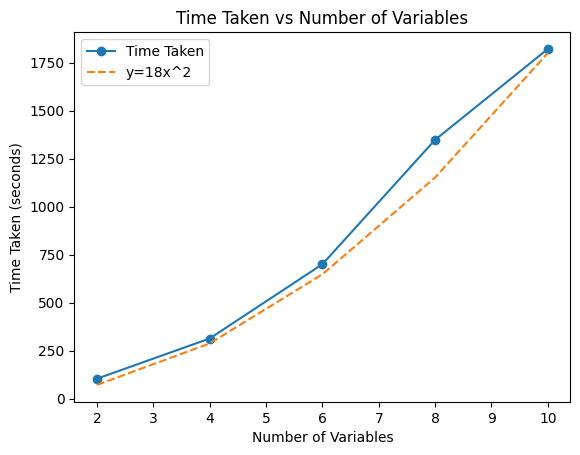

In [ ]:
# plot the time curve
# attach y=x^2
import matplotlib.pyplot as plt

plt.plot(range(2,11,2), time_arr, marker='o')
plt.plot(range(2,11,2), [18*x**2 for x in range(2,11,2)], linestyle='--')
plt.xlabel('Number of Variables')
plt.ylabel('Time Taken (seconds)')
plt.legend(['Time Taken', 'y=18x^2'])
plt.title('Time Taken vs Number of Variables')
plt.show()

change number of objectives m from 2 to 10, find the variation of time
test: 2,4,6,8,10
to save time, we can leave sample number=2, and it can be easily changed to a larger value

conclusion: time is in $O(n^2)$ with increasing of the number of variables

In [ ]:
# toy example
A_VARS_test = deepcopy(A_VARS)

def prepare_A_OBJ(num_obj):
    A_OBJ_test = {}
    for i in range(8,8+num_obj):
        A_OBJ_test[i] = [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}]
    return A_OBJ_test

# print(prepare_A_OBJ(3))
sample_num=1
time_arr=[]
for j in range(2,11,2):
    A_VARS_test = prepare_A_VARS(j, tunable_current)
    print(f"Number of variables: {j}, Current positions: {list(A_VARS_test.keys())}, {A_VARS_test}")
    A_OBJ_test = {
        40: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
        42: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
    }
    time_arr.append(total_scan_execution(A_VARS_test, A_OBJ_test, sample_num)[-1])
    


Number of variables: 2, Current positions: [1, 3], {1: ['I', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17A94A480>], 3: ['I2', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17A9489A0>]}
Scan current variables from position: [1, 3]
Scan objectives from position: ['alpha_x=0.0 @ position 40 with weight 1.0', 'alpha_y=0.0 @ position 42 with weight 1.0']
Total time taken without multiprocessing: 119.1357 seconds
Time log: {'time_mse': 11.730830669403076, 'time_jac': 19.01674485206604, 'time_hess': 88.36049771308899, 'time_eig': 0.014051198959350586}
Number of variables: 4, Current positions: [1, 3, 10, 16], {1: ['I', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17AA3AFC0>], 3: ['I2', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17E963420>], 10: ['I3', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A17E963600>], 16: ['I4', 'current', <function prepare_A_VARS.<locals>.<lambda> at 0x000001A1

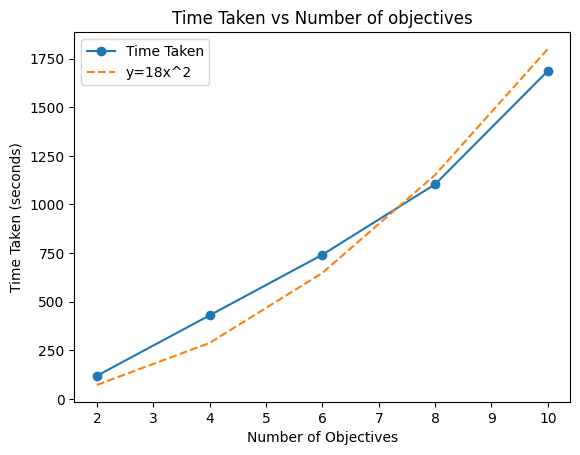

In [ ]:
# plot the time curve
# attach y=x^2
import matplotlib.pyplot as plt

plt.plot(range(2,11,2), time_arr, marker='o')
plt.plot(range(2,11,2), [18*x**2 for x in range(2,11,2)], linestyle='--')
plt.xlabel('Number of Objectives')
plt.ylabel('Time Taken (seconds)')
plt.legend(['Time Taken', 'y=18x^2'])
plt.title('Time Taken vs Number of objectives')
plt.show()

conclusion: time is in $O(m^2)$ with increasing of the number of objectives